`cifar10-0913` 실험(12개 developmental 조건, net 3개씩)에서 학습된 모든 체크포인트에 대해

1. Clean CIFAR-10 test accuracy
2. CIFAR-10-C corruption robustness (Hendrycks)
3. cifar10c color-conflict decision rate (shape vs color bias)
4. 실제 reCAPTCHA 그리드 태스크 (car 칸 선택)
5. Geirhos texture-shape cue-conflict shape bias


In [1]:
import os
import re
import json
import zipfile
import urllib.request

import numpy as np
import torch
import torch.nn as nn
import torchvision
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import transforms as T
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd

import sys
sys.path.append('..')
from src.data.degredation import get_transforms
from src.data.dataset import CustomDataset
from src.models.resnet import resnet18
from src.training.train import test

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

dataset_dir = '../dataset'
figure_dir = os.path.join("..", "figures", "evaluation_all")
os.makedirs(figure_dir, exist_ok=True)

CIFAR10_CLASSES = ["airplane", "automobile", "bird", "cat", "deer",
                    "dog", "frog", "horse", "ship", "truck"]
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD = (0.2023, 0.1994, 0.2010)  # src/data/degredation.py와 동일 -- 실제 학습에 쓰인 값
criterion = nn.CrossEntropyLoss()
SAVE_FIGURES = False  # True로 바꾸면 figures/에 svg 저장 -- 기본은 화면 표시만, 디스크 절약


cuda


In [2]:
class AttrlessDataset(Dataset):
    """torchvision류 (image, label) 2-tuple -> train()/test()가 기대하는 (image, label, attr) 3-tuple."""
    def __init__(self, base_dataset):
        self.base_dataset = base_dataset

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        image, label = self.base_dataset[idx]
        return image, label, -1


In [3]:
save_dir = os.path.join("..", "results", "cifar10-0913") # model dir 
num_net = 3

model_tags = [
    "wo", "r", "g", "l5_0.001", "l5_0.01", "rg",
    "rl_g10l5_0.001", "gl_g10l5_0.001",
    "rgl_g10l5_0.001", "rgl_g10l5_0.005", "rgl_g10l5_0.01",
    "rgl_g10l10_0.001", "rgl_g10l10_0.005", "rgl_g10l10_0.01",
    "rgl_g5l5_0.001", "rgl_g5l5_0.01",
]

def ckpt_path(tag, net_idx):
    return os.path.join(save_dir, f"best_model_{tag}_{net_idx}.pth")

def load_model(tag, net_idx):
    model = resnet18().to(device)
    model.load_state_dict(torch.load(ckpt_path(tag, net_idx), map_location=device))
    model.eval()
    return model

available_tags = [t for t in model_tags if all(os.path.exists(ckpt_path(t, i)) for i in range(num_net))]
missing_tags = [t for t in model_tags if t not in available_tags]
print(f"available: {available_tags}")
if missing_tags:
    print(f"missing : {missing_tags}")


available: ['wo', 'r', 'g', 'l5_0.001', 'l5_0.01', 'rg', 'rl_g10l5_0.001', 'gl_g10l5_0.001', 'rgl_g10l5_0.001', 'rgl_g10l5_0.005', 'rgl_g10l5_0.01', 'rgl_g10l10_0.001', 'rgl_g10l10_0.005', 'rgl_g10l10_0.01', 'rgl_g5l5_0.001', 'rgl_g5l5_0.01']


1. Clean CIFAR-10 test accuracy

일반 전처리(blur=0, color=1)로 표준 test set 정확도. net 3개 평균/표준편차.

In [4]:
cifar_test_normal = AttrlessDataset(torchvision.datasets.CIFAR10(
    root=dataset_dir, train=False, download=True,
    transform=get_transforms("cifar10", blur=0, color=1, test=True),
))
cifar_test_loader = DataLoader(cifar_test_normal, batch_size=256, shuffle=False, num_workers=0)
print(f"test size: {len(cifar_test_normal)}")


test size: 10000


In [5]:
clean_acc_results = {}
for tag in available_tags:
    accs = []
    for net_idx in range(num_net):
        model = load_model(tag, net_idx)
        _, acc = test(model, cifar_test_loader, criterion, device)
        accs.append(acc)
    clean_acc_results[tag] = accs
    print(f"{tag:16s}: clean acc {np.mean(accs)*100:.2f} (+/- {np.std(accs)*100:.2f})")


wo              : clean acc 90.36 (+/- 0.03)
r               : clean acc 90.06 (+/- 0.70)
g               : clean acc 90.43 (+/- 0.15)
l5_0.001        : clean acc 91.50 (+/- 0.20)
l5_0.01         : clean acc 85.80 (+/- 0.82)
rg              : clean acc 90.15 (+/- 0.25)
rl_g10l5_0.001  : clean acc 89.91 (+/- 0.23)
gl_g10l5_0.001  : clean acc 89.92 (+/- 0.06)
rgl_g10l5_0.001 : clean acc 88.56 (+/- 0.12)
rgl_g10l5_0.005 : clean acc 85.08 (+/- 1.57)
rgl_g10l5_0.01  : clean acc 80.78 (+/- 0.13)
rgl_g10l10_0.001: clean acc 89.06 (+/- 0.10)
rgl_g10l10_0.005: clean acc 85.92 (+/- 0.26)
rgl_g10l10_0.01 : clean acc 84.27 (+/- 0.66)
rgl_g5l5_0.001  : clean acc 88.59 (+/- 0.51)
rgl_g5l5_0.01   : clean acc 81.45 (+/- 1.02)


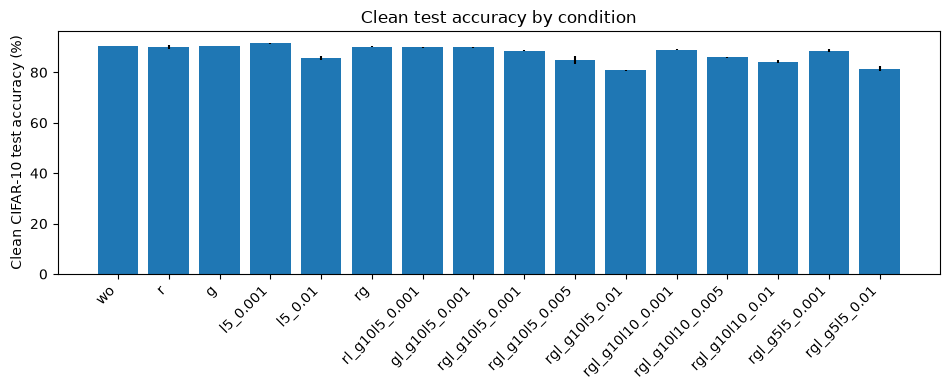

In [6]:
tags = list(clean_acc_results.keys())
means = [np.mean(clean_acc_results[t]) * 100 for t in tags]
stds = [np.std(clean_acc_results[t]) * 100 for t in tags]

plt.figure(figsize=(max(6, len(tags) * 0.6), 4))
plt.bar(range(len(tags)), means, yerr=stds)
plt.xticks(range(len(tags)), tags, rotation=45, ha='right')
plt.ylabel("Clean CIFAR-10 test accuracy (%)")
plt.title("Clean test accuracy by condition")
plt.tight_layout()
if SAVE_FIGURES:
    plt.savefig(os.path.join(figure_dir, "01_clean_accuracy.svg"))
plt.show()


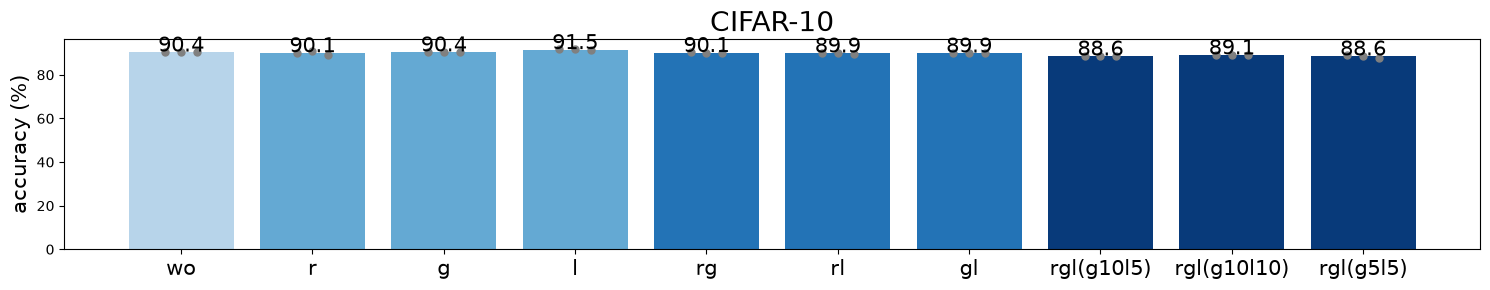

In [87]:
schedule_tags_order = [
    "wo", "r", "g", "l5_0.001", "rg",
    "rl_g10l5_0.001", "gl_g10l5_0.001",
    "rgl_g10l5_0.001", "rgl_g10l10_0.001", "rgl_g5l5_0.001",
]
schedule_labels = {
    "wo": "wo", "r": "r", "g": "g", "l5_0.001": "l", "rg": "rg",
    "rl_g10l5_0.001": "rl", "gl_g10l5_0.001": "gl",
    "rgl_g10l5_0.001": "rgl(g10l5)", "rgl_g10l10_0.001": "rgl(g10l10)", "rgl_g5l5_0.001": "rgl(g5l5)",
}
factor_count = {
    "wo": 0,
    "r": 1, "g": 1, "l5_0.001": 1,
    "rg": 2, "rl_g10l5_0.001": 2, "gl_g10l5_0.001": 2,
    "rgl_g10l5_0.001": 3, "rgl_g10l10_0.001": 3, "rgl_g5l5_0.001": 3,
}

schedule_tags = [t for t in schedule_tags_order if t in clean_acc_results]
missing_schedule_tags = [t for t in schedule_tags_order if t not in clean_acc_results]

means = [np.mean(clean_acc_results[t]) * 100 for t in schedule_tags]
dot_offsets = [-0.12, 0.0, 0.12]  # num_net=3

cmap = plt.get_cmap("Blues")
bar_colors = [cmap(0.3 + 0.22 * factor_count[t]) for t in schedule_tags]  # 0factor=연하게 ~ 3factor=진하게

plt.figure(figsize=(15, 3))
plt.bar(range(len(schedule_tags)), means, color=bar_colors, zorder=2)
for xi, tag in enumerate(schedule_tags):
    accs = np.array(clean_acc_results[tag]) * 100
    for off, acc in zip(dot_offsets, accs):
        plt.scatter(xi + off, acc, color="gray", s=25, zorder=3)

for xi, m in enumerate(means):
    plt.text(xi, m + 0.3, f"{m:.1f}", ha="center", fontsize=15)

plt.xticks(range(len(schedule_tags)), [schedule_labels[t] for t in schedule_tags], fontsize=15) # rotation 
plt.ylabel("accuracy (%)", fontsize=15)
plt.title("CIFAR-10", fontsize=20)
plt.tight_layout()
plt.show()

1b. 실제로 뭘 틀렸는지 육안 확인 (clean CIFAR-10)

`show_clean_misclassified(tag, net_idx)`를 호출하면 그 모델이 clean test set에서 틀린 이미지 중
무작위 12장을 true/pred 라벨과 함께 보여줌.

rgl_g10l10_0.001 net0: 1110/10000 wrong (11.1%)


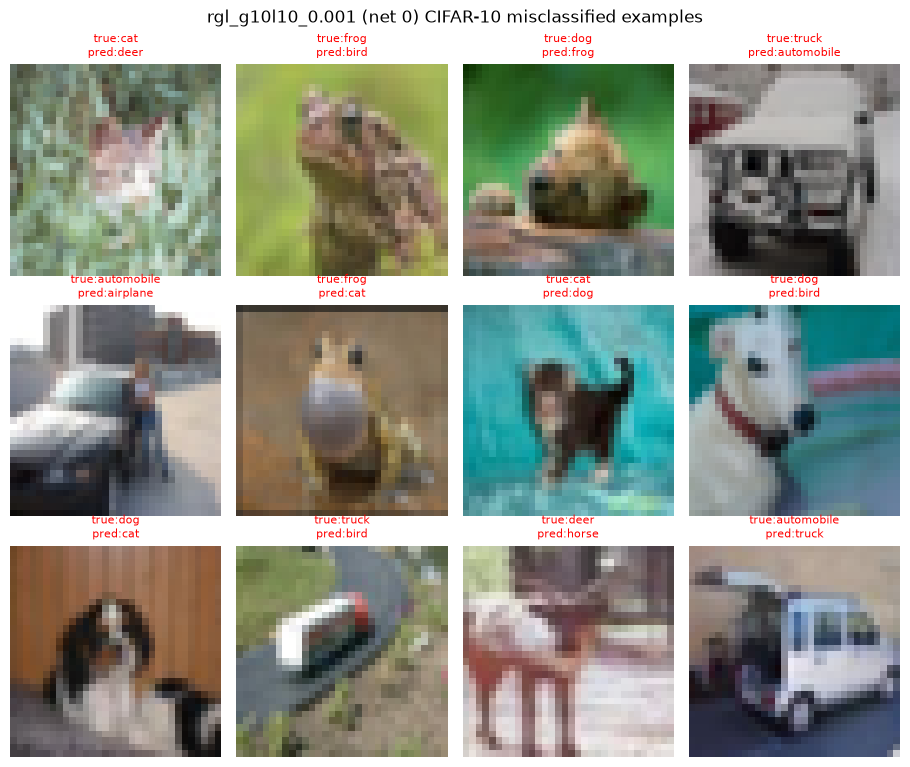

In [7]:
def unnormalize_cifar(x):
    mean = torch.tensor(CIFAR10_MEAN).view(3, 1, 1)
    std = torch.tensor(CIFAR10_STD).view(3, 1, 1)
    return (x.cpu() * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()


def _grid_show(items, render_fn, title, ncols=4):
    """items: 보여줄 항목 리스트. render_fn(ax, item)이 실제로 이미지+제목을 그림."""
    nrows = int(np.ceil(len(items) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.3, nrows * 2.6))
    axes = np.array(axes).reshape(-1)
    for ax, item in zip(axes, items):
        render_fn(ax, item)
        ax.axis("off")
    for ax in axes[len(items):]:
        ax.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


def show_clean_misclassified(tag, net_idx=0, num_examples=12, seed=0):
    """clean CIFAR-10 test set에서 이 모델이 틀린 이미지 중 무작위로 보여줌."""
    model = load_model(tag, net_idx)
    model.eval()
    imgs, labels, preds = [], [], []
    with torch.no_grad():
        for inputs, lbls, _ in cifar_test_loader:
            p = model(inputs.to(device)).argmax(1).cpu()
            imgs.append(inputs)
            labels.append(lbls)
            preds.append(p)
    imgs, labels, preds = torch.cat(imgs), torch.cat(labels), torch.cat(preds)

    wrong_idx = (preds != labels).nonzero(as_tuple=True)[0].numpy()
    print(f"{tag} net{net_idx}: {len(wrong_idx)}/{len(labels)} wrong ({len(wrong_idx) / len(labels) * 100:.1f}%)")
    chosen = np.random.RandomState(seed).choice(wrong_idx, min(num_examples, len(wrong_idx)), replace=False)

    def render(ax, idx):
        ax.imshow(unnormalize_cifar(imgs[idx]))
        ax.set_title(f"true:{CIFAR10_CLASSES[labels[idx]]}\npred:{CIFAR10_CLASSES[preds[idx]]}",
                     fontsize=8, color="red")

    _grid_show(chosen, render, f"{tag} (net {net_idx}) CIFAR-10 misclassified examples")

show_clean_misclassified("rgl_g10l10_0.001", 0)

2. CIFAR-10-C corruption robustness (Hendrycks)

19개 corruption 타입에 대한 강건성

In [8]:
import tarfile

cifar10c_root = os.path.join(dataset_dir, "CIFAR-10-C")
cifar10c_url = "https://zenodo.org/records/2535967/files/CIFAR-10-C.tar?download=1"
labels_path = os.path.join(cifar10c_root, "labels.npy")
tar_path = os.path.join(dataset_dir, "CIFAR-10-C.tar")

if not os.path.exists(labels_path):
    need_download = True
    if os.path.exists(tar_path):
        try:
            with tarfile.open(tar_path) as tar:
                tar.getmembers()
            need_download = False
        except (tarfile.TarError, EOFError):
            os.remove(tar_path)
    if need_download:
        urllib.request.urlretrieve(cifar10c_url, tar_path)
    print("Extracting CIFAR-10-C...")
    with tarfile.open(tar_path) as tar:
        tar.extractall(dataset_dir, filter="data")
    print("Done.")
    if os.path.exists(tar_path):
        os.remove(tar_path)  

CORRUPTIONS = [
    "brightness", "contrast", "defocus_blur", "elastic_transform", "fog", "frost",
    "gaussian_blur", "gaussian_noise", "glass_blur", "impulse_noise", "jpeg_compression",
    "motion_blur", "pixelate", "saturate", "shot_noise", "snow", "spatter",
    "speckle_noise", "zoom_blur",
]


In [9]:
c10c_transform = get_transforms("cifar10", blur=0, color=1, test=True)
CORRUPTION_SUBSAMPLE = 2000  # 전체 예산 -- severity 5개로 나눠서 씀
SEVERITIES = [1, 2, 3, 4, 5]
PER_SEVERITY_SUBSAMPLE = CORRUPTION_SUBSAMPLE // len(SEVERITIES)  # 400/severity, 총 계산량은 기존과 동일

class CIFAR10CDataset(Dataset):
    def __init__(self, images, labels, transform):
        self.images = images  # (N, 32, 32, 3) uint8
        self.labels = labels
        self.transform = transform
    def __len__(self):
        return len(self.images)
    def __getitem__(self, idx):
        img = Image.fromarray(self.images[idx])
        return self.transform(img), int(self.labels[idx])


def evaluate_corruption_robustness_detailed(model, batch_size=256, per_severity_subsample=PER_SEVERITY_SUBSAMPLE, seed=0):
    """corruption(19) x severity(1~5)"""
    labels_full = np.load(labels_path)
    rng = np.random.RandomState(seed)
    severity_idx = {
        sev: rng.choice(np.arange((sev - 1) * 10000, sev * 10000),
                         min(per_severity_subsample, 10000), replace=False)
        for sev in SEVERITIES
    }
    model.eval()
    results = {}
    for corruption in CORRUPTIONS:
        path = os.path.join(cifar10c_root, f"{corruption}.npy")
        if not os.path.exists(path):
            continue
        arr = np.load(path, mmap_mode='r')
        results[corruption] = {}
        for sev, idx in severity_idx.items():
            images = arr[idx]
            lbls = labels_full[idx]
            loader = DataLoader(CIFAR10CDataset(images, lbls, c10c_transform),
                                 batch_size=batch_size, shuffle=False, num_workers=0)
            correct, total = 0, 0
            with torch.no_grad():
                for x, y in loader:
                    x, y = x.to(device), y.to(device)
                    correct += (model(x).argmax(1) == y).sum().item()
                    total += y.size(0)
            results[corruption][sev] = correct / total
    return results


In [10]:
corruption_detailed = {}   # corruption_detailed[tag] = net별 {corruption: {severity: acc}} 리스트
corruption_results = {}    # 기존 요약(전체 평균) -- eval2_plot 호환용
for tag in available_tags:
    per_net_detail = []
    overall_means = []
    for net_idx in range(num_net):
        model = load_model(tag, net_idx)
        detail = evaluate_corruption_robustness_detailed(model)
        per_net_detail.append(detail)
        all_vals = [acc for sevs in detail.values() for acc in sevs.values()]
        overall_means.append(np.mean(all_vals))
    corruption_detailed[tag] = per_net_detail
    corruption_results[tag] = dict(mean=np.mean(overall_means), std=np.std(overall_means))
    print(f"{tag:16s}: mean corruption acc {np.mean(overall_means)*100:.2f}±{np.std(overall_means)*100:.2f}")


wo              : mean corruption acc 72.89±0.55
r               : mean corruption acc 70.98±1.40
g               : mean corruption acc 74.77±0.91
l5_0.001        : mean corruption acc 71.39±0.23
l5_0.01         : mean corruption acc 68.27±0.57
rg              : mean corruption acc 73.58±0.55
rl_g10l5_0.001  : mean corruption acc 67.25±0.98
gl_g10l5_0.001  : mean corruption acc 74.78±0.28
rgl_g10l5_0.001 : mean corruption acc 72.62±0.62
rgl_g10l5_0.005 : mean corruption acc 72.37±0.80
rgl_g10l5_0.01  : mean corruption acc 70.54±1.13
rgl_g10l10_0.001: mean corruption acc 74.68±0.35
rgl_g10l10_0.005: mean corruption acc 75.34±0.33
rgl_g10l10_0.01 : mean corruption acc 74.25±0.28
rgl_g5l5_0.001  : mean corruption acc 72.47±0.30
rgl_g5l5_0.01   : mean corruption acc 70.57±0.83


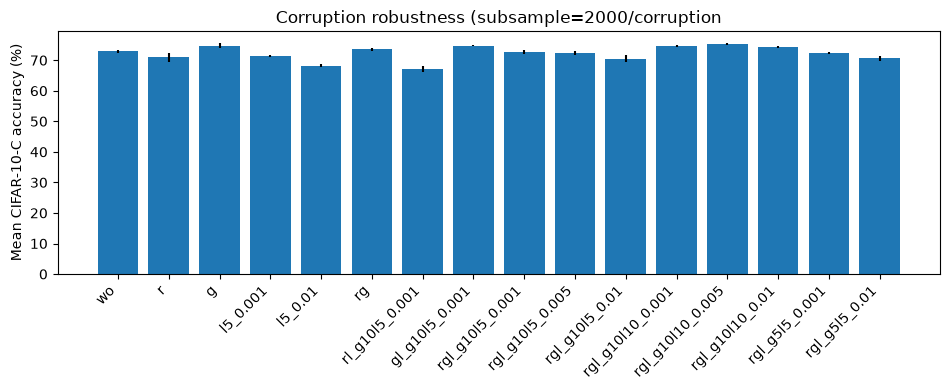

In [11]:
tags = list(corruption_results.keys())
means = [corruption_results[t]["mean"] * 100 for t in tags]
stds = [corruption_results[t]["std"] * 100 for t in tags]

plt.figure(figsize=(max(6, len(tags) * 0.6), 4))
plt.bar(range(len(tags)), means, yerr=stds)
plt.xticks(range(len(tags)), tags, rotation=45, ha='right')
plt.ylabel("Mean CIFAR-10-C accuracy (%)")
plt.title(f"Corruption robustness (subsample={CORRUPTION_SUBSAMPLE}/corruption")
plt.tight_layout()
if SAVE_FIGURES:
    plt.savefig(os.path.join(figure_dir, "02_corruption_robustness.svg"))
plt.show()


### 2b. Corruption 타입별 / 강도(severity)별로 나눠보기

위 평균 하나로는 "어떤 종류의 왜곡에 특히 약한지", "약한 강도에서만 괜찮은 건지 강한 강도에서도
버티는지"가 안 보임. 그래서 19개 corruption 타입 x 5단계 severity로 쪼갠 결과를 히트맵 2개로 봄
(타입별 히트맵은 severity 평균, severity별 히트맵은 타입 평균).

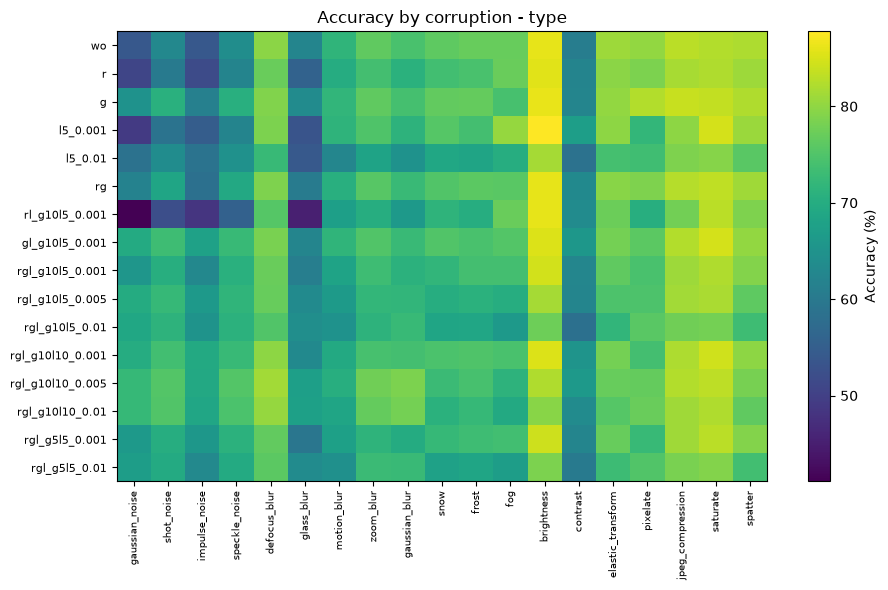

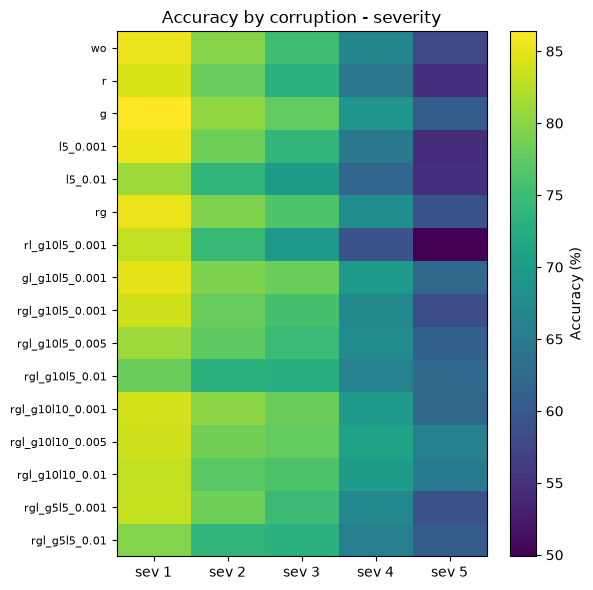

In [32]:
# Hendrycks 표준 4-카테고리 + 원 논문의 "extra 4"(speckle_noise/gaussian_blur/spatter/saturate)는
# 각자 제일 가까운 카테고리에 붙임 -- 19개 전부 보이게 하려고.
CORRUPTION_CATEGORIES = {
    "noise":   ["gaussian_noise", "shot_noise", "impulse_noise", "speckle_noise"],
    "blur":    ["defocus_blur", "glass_blur", "motion_blur", "zoom_blur", "gaussian_blur"],
    "weather": ["snow", "frost", "fog", "brightness"],
    "digital": ["contrast", "elastic_transform", "pixelate", "jpeg_compression", "saturate", "spatter"],
}
corruption_order = [c for cat in CORRUPTION_CATEGORIES.values() for c in cat if c in CORRUPTIONS]
tags_list = list(corruption_detailed.keys())

# 1) condition x corruption-type 히트맵 (severity + net 평균)
type_matrix = np.zeros((len(tags_list), len(corruption_order)))
for i, tag in enumerate(tags_list):
    for j, corr in enumerate(corruption_order):
        vals = [detail[corr][sev] for detail in corruption_detailed[tag] for sev in SEVERITIES]
        type_matrix[i, j] = np.mean(vals) * 100

plt.figure(figsize=(max(9, len(corruption_order) * 0.5), max(6, len(tags_list) * 0.35)))
im = plt.imshow(type_matrix, aspect='auto', cmap='viridis')
plt.colorbar(im, label="Accuracy (%)")
plt.xticks(range(len(corruption_order)), corruption_order, rotation=90, fontsize=7)
plt.yticks(range(len(tags_list)), tags_list, fontsize=8)
plt.title("Accuracy by corruption - type")
plt.tight_layout()
if SAVE_FIGURES:
    plt.savefig(os.path.join(figure_dir, "02b_corruption_type_heatmap.svg"))
plt.show()

# 2) condition x severity 히트맵 (타입 + net 평균)
sev_matrix = np.zeros((len(tags_list), len(SEVERITIES)))
for i, tag in enumerate(tags_list):
    for j, sev in enumerate(SEVERITIES):
        vals = [detail[corr][sev] for detail in corruption_detailed[tag] for corr in detail]
        sev_matrix[i, j] = np.mean(vals) * 100

plt.figure(figsize=(6, max(6, len(tags_list) * 0.35)))
im = plt.imshow(sev_matrix, aspect='auto', cmap='viridis')
plt.colorbar(im, label="Accuracy (%)")
plt.xticks(range(len(SEVERITIES)), [f"sev {s}" for s in SEVERITIES])
plt.yticks(range(len(tags_list)), tags_list, fontsize=8)
plt.title("Accuracy by corruption - severity")
plt.tight_layout()
if SAVE_FIGURES:
    plt.savefig(os.path.join(figure_dir, "02c_corruption_severity_heatmap.svg"))
plt.show()

3. cifar10c color-conflict decision rate (shape vs color bias)

색깔 편향 있는 학습 이미지는 안 봤지만, color-conflict test set에서도 모양(shape)으로 판단하는지 보는 일반화/강건성 지표

In [13]:
cifar10c_percent = "0.5pct"
cifar10c_test_conflict = CustomDataset(
    "cifar10c", dataset_dir, split="test-conflict", percent=cifar10c_percent,
    transform=get_transforms("cifar10c", blur=0, color=1, test=True),
)
cifar10c_conflict_loader = DataLoader(cifar10c_test_conflict, batch_size=128, shuffle=False, num_workers=0)
print(f"cifar10c test-conflict size: {len(cifar10c_test_conflict)}")


def evaluate_decision_rate(model, loader):
    model.eval()
    labels_list, attrs_list, preds_list = [], [], []
    with torch.no_grad():
        for inputs, labels, attrs in loader:
            inputs = inputs.to(device)
            preds = model(inputs).argmax(1).cpu().numpy()
            labels_list.append(labels.numpy())
            attrs_list.append(attrs.numpy())
            preds_list.append(preds)
    labels_arr = np.concatenate(labels_list)
    attrs_arr = np.concatenate(attrs_list)
    preds_arr = np.concatenate(preds_list)

    decision_rates = []
    for c in range(10):
        idx = np.where(labels_arr == c)[0]
        correct_label = np.sum(preds_arr[idx] == labels_arr[idx])
        correct_attr = np.sum(preds_arr[idx] == attrs_arr[idx])
        denom = correct_label + correct_attr
        decision_rates.append(correct_label / denom if denom > 0 else np.nan)
    return decision_rates


cifar10c test-conflict size: 9000


In [14]:
cifar10c_decision_results = {}
for tag in available_tags:
    per_net = []
    for net_idx in range(num_net):
        model = load_model(tag, net_idx)
        per_net.append(evaluate_decision_rate(model, cifar10c_conflict_loader))
    cifar10c_decision_results[tag] = np.array(per_net)
    print(f"{tag:16s}: overall decision rate {np.nanmean(per_net):.4f} (+/- {np.nanstd(per_net):.4f})")


wo              : overall decision rate 0.9305 (+/- 0.0334)
r               : overall decision rate 0.9435 (+/- 0.0188)
g               : overall decision rate 0.9428 (+/- 0.0227)
l5_0.001        : overall decision rate 0.9253 (+/- 0.0302)
l5_0.01         : overall decision rate 0.9028 (+/- 0.0350)
rg              : overall decision rate 0.9353 (+/- 0.0263)
rl_g10l5_0.001  : overall decision rate 0.9118 (+/- 0.0331)
gl_g10l5_0.001  : overall decision rate 0.9236 (+/- 0.0373)
rgl_g10l5_0.001 : overall decision rate 0.9133 (+/- 0.0385)
rgl_g10l5_0.005 : overall decision rate 0.9036 (+/- 0.0393)
rgl_g10l5_0.01  : overall decision rate 0.8902 (+/- 0.0406)
rgl_g10l10_0.001: overall decision rate 0.9293 (+/- 0.0273)
rgl_g10l10_0.005: overall decision rate 0.9018 (+/- 0.0404)
rgl_g10l10_0.01 : overall decision rate 0.8911 (+/- 0.0382)
rgl_g5l5_0.001  : overall decision rate 0.9251 (+/- 0.0316)
rgl_g5l5_0.01   : overall decision rate 0.8913 (+/- 0.0391)


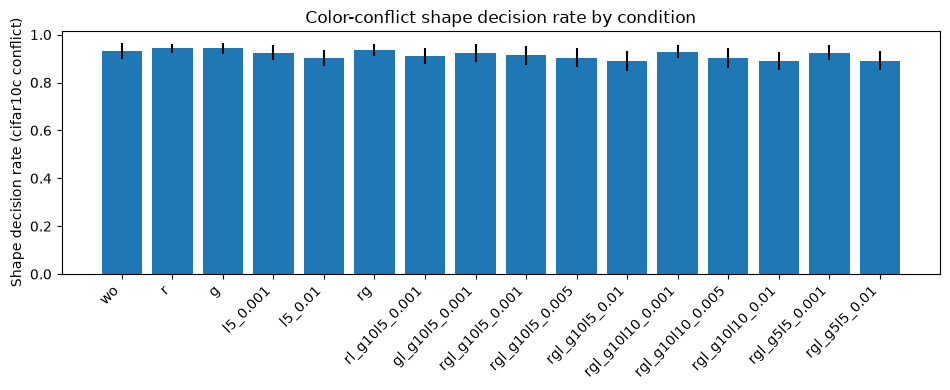

In [15]:
tags = list(cifar10c_decision_results.keys())
means = [np.nanmean(cifar10c_decision_results[t]) for t in tags]
stds = [np.nanstd(cifar10c_decision_results[t]) for t in tags]

plt.figure(figsize=(max(6, len(tags) * 0.6), 4))
plt.bar(range(len(tags)), means, yerr=stds)
plt.xticks(range(len(tags)), tags, rotation=45, ha='right')
plt.ylabel("Shape decision rate (cifar10c conflict)")
plt.title("Color-conflict shape decision rate by condition")
plt.tight_layout()
if SAVE_FIGURES:
    plt.savefig(os.path.join(figure_dir, "03_cifar10c_decision_rate.svg"))
plt.show()


### 3b. 실제로 색깔을 따라간 이미지 육안 확인 (cifar10c color-conflict)

`show_cifar10c_color_wins(tag, net_idx)` -- 모델이 모양(정답 라벨) 대신 색깔(attr)을 따라간
(=색깔 클래스로 예측한) 이미지들만 골라서 보여줌.

wo net0: 609/9000 predicted color-attr instead of shape


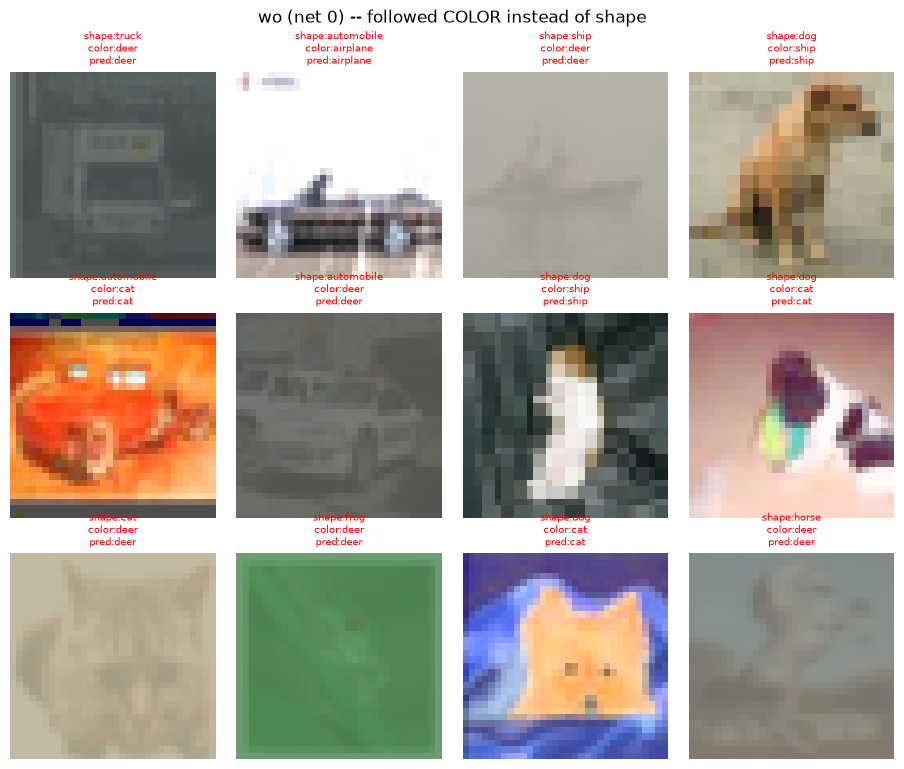

rgl_g10l5_0.01 net0: 606/9000 predicted color-attr instead of shape


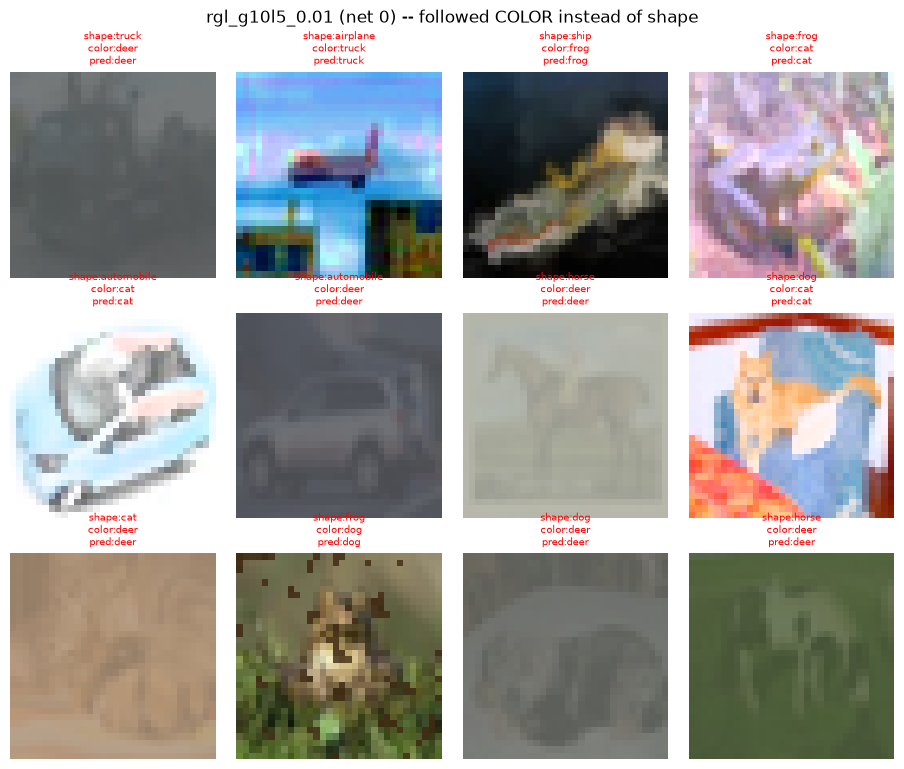

In [ ]:
def show_cifar10c_color_wins(tag, net_idx=0, num_examples=12, seed=0):
    """cifar10c conflict set에서, 모델이 모양(label) 대신 색깔(attr)로 예측한 이미지만 보여줌."""
    model = load_model(tag, net_idx)
    model.eval()
    imgs, labels, attrs, preds = [], [], [], []
    with torch.no_grad():
        for inputs, lbls, attr in cifar10c_conflict_loader:
            p = model(inputs.to(device)).argmax(1).cpu()
            imgs.append(inputs)
            labels.append(lbls)
            attrs.append(attr)
            preds.append(p)
    imgs, labels, attrs, preds = torch.cat(imgs), torch.cat(labels), torch.cat(attrs), torch.cat(preds)

    color_win_idx = ((preds == attrs) & (preds != labels)).nonzero(as_tuple=True)[0].numpy()
    print(f"{tag} net{net_idx}: {len(color_win_idx)}/{len(labels)} predicted color-attr instead of shape")
    chosen = np.random.RandomState(seed).choice(color_win_idx, min(num_examples, len(color_win_idx)), replace=False)

    def render(ax, idx):
        ax.imshow(unnormalize_cifar(imgs[idx]))
        ax.set_title(f"shape:{CIFAR10_CLASSES[labels[idx]]}\ncolor:{CIFAR10_CLASSES[attrs[idx]]}\npred:{CIFAR10_CLASSES[preds[idx]]}",
                     fontsize=7, color="red")

    _grid_show(chosen, render, f"{tag} (net {net_idx}) -- followed COLOR instead of shape")


show_cifar10c_color_wins("wo", 0)

4. 실제 reCAPTCHA 그리드 태스크

https://github.com/ajmandourah/recaptcha-dataset 그리드에서 car 칸을 전부 골라야 하는 실제 세계 검증

In [17]:
import random

recaptcha_root = os.path.join(dataset_dir, "recaptcha-dataset", "Training")
car_dir = os.path.join(recaptcha_root, "Car")
noncar_dirs = [d for d in os.listdir(recaptcha_root)
               if d not in ("Car", "Other") and os.path.isdir(os.path.join(recaptcha_root, d))]

car_files = [os.path.join(car_dir, f) for f in os.listdir(car_dir)]
noncar_files = []
for d in noncar_dirs:
    p = os.path.join(recaptcha_root, d)
    noncar_files += [os.path.join(p, f) for f in os.listdir(p)]

print(f"car images: {len(car_files)}, non-car images: {len(noncar_files)} (from {noncar_dirs})")

recaptcha_transform = T.Compose([
    T.Resize((32, 32)),
    T.ToTensor(),
    T.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])
AUTOMOBILE_IDX = CIFAR10_CLASSES.index("automobile")


def load_recaptcha_image(path):
    img = Image.open(path).convert("RGB")
    return recaptcha_transform(img)


def recaptcha_grid_eval(model, grid_size=4, num_trials=100, seed=0):
    rng = random.Random(seed)
    cells_n = grid_size * grid_size
    model.eval()
    exact_matches, cell_correct = 0, 0
    for _ in range(num_trials):
        n_car = rng.randint(1, cells_n - 1)
        chosen_car = rng.sample(car_files, n_car)
        chosen_noncar = rng.sample(noncar_files, cells_n - n_car)
        paths = chosen_car + chosen_noncar
        true_hits = [True] * n_car + [False] * (cells_n - n_car)
        order = list(range(cells_n))
        rng.shuffle(order)
        paths = [paths[i] for i in order]
        true_hits = [true_hits[i] for i in order]

        images = torch.stack([load_recaptcha_image(p) for p in paths]).to(device)
        with torch.no_grad():
            preds = model(images).argmax(1).cpu().tolist()
        pred_hits = [p == AUTOMOBILE_IDX for p in preds]

        if pred_hits == true_hits:
            exact_matches += 1
        cell_correct += sum(p == t for p, t in zip(pred_hits, true_hits))
    return exact_matches / num_trials, cell_correct / (num_trials * cells_n)


car images: 3504, non-car images: 6116 (from ['Bicycle', 'Bridge', 'Bus', 'Chimney', 'Crosswalk', 'Hydrant', 'Motorcycle', 'Mountain', 'Palm', 'Traffic Light'])


In [18]:
recaptcha_results = {}
for tag in available_tags:
    per_net = []
    for net_idx in range(num_net):
        model = load_model(tag, net_idx)
        exact_rate, cell_acc = recaptcha_grid_eval(model, grid_size=4, num_trials=100, seed=net_idx)
        per_net.append((exact_rate, cell_acc))
    recaptcha_results[tag] = per_net
    exact_vals = [x[0] for x in per_net]
    cell_vals = [x[1] for x in per_net]
    print(f"{tag:16s}: grid pass rate {np.mean(exact_vals)*100:.1f}% (+/- {np.std(exact_vals)*100:.1f})  |  cell acc {np.mean(cell_vals)*100:.2f}%")


wo              : grid pass rate 0.3% (+/- 0.5)  |  cell acc 53.71%
r               : grid pass rate 1.0% (+/- 0.0)  |  cell acc 53.54%
g               : grid pass rate 0.3% (+/- 0.5)  |  cell acc 53.25%
l5_0.001        : grid pass rate 1.0% (+/- 0.8)  |  cell acc 54.94%
l5_0.01         : grid pass rate 0.3% (+/- 0.5)  |  cell acc 53.60%
rg              : grid pass rate 0.7% (+/- 0.5)  |  cell acc 53.25%
rl_g10l5_0.001  : grid pass rate 1.0% (+/- 0.8)  |  cell acc 54.23%
gl_g10l5_0.001  : grid pass rate 0.7% (+/- 0.9)  |  cell acc 54.04%
rgl_g10l5_0.001 : grid pass rate 0.7% (+/- 0.9)  |  cell acc 53.19%
rgl_g10l5_0.005 : grid pass rate 0.3% (+/- 0.5)  |  cell acc 52.73%
rgl_g10l5_0.01  : grid pass rate 0.3% (+/- 0.5)  |  cell acc 52.42%
rgl_g10l10_0.001: grid pass rate 0.3% (+/- 0.5)  |  cell acc 52.71%
rgl_g10l10_0.005: grid pass rate 0.3% (+/- 0.5)  |  cell acc 52.69%
rgl_g10l10_0.01 : grid pass rate 0.3% (+/- 0.5)  |  cell acc 52.54%
rgl_g5l5_0.001  : grid pass rate 0.3% (+/- 0.5) 

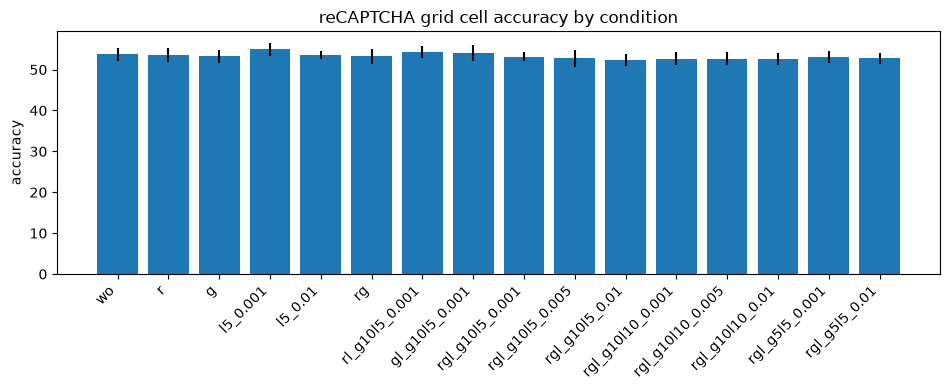

In [59]:
tags = list(recaptcha_results.keys())
cell_means = [np.mean([x[1] for x in recaptcha_results[t]]) * 100 for t in tags]
cell_stds = [np.std([x[1] for x in recaptcha_results[t]]) * 100 for t in tags]

plt.figure(figsize=(max(6, len(tags) * 0.6), 4))
plt.bar(range(len(tags)), cell_means, yerr=cell_stds)
plt.xticks(range(len(tags)), tags, rotation=45, ha='right')
plt.ylabel("accuracy")
plt.title("reCAPTCHA grid cell accuracy by condition")
plt.tight_layout()
if SAVE_FIGURES:
    plt.savefig(os.path.join(figure_dir, "04_recaptcha.svg"))
plt.show()


### 4b. 실제 그리드에 어떤 이미지가 들어갔고 모델이 어떻게 판단했는지 확인

`show_recaptcha_trial(tag, net_idx)` -- reCAPTCHA 그리드 한 판을 실제로 만들어서, 각 칸의 이미지와 true label(CAR/non-car), 모델 예측을 같이 보여줌 (초록=맞음, 빨강=틀림).

In [ ]:
def show_recaptcha_trial(tag, net_idx=0, grid_size=4, seed=0):
    """reCAPTCHA 그리드 한 판을 실제로 만들어서, 어떤 이미지가 들어갔고
    모델이 무엇으로 판단했는지를 그림으로 보여줌."""
    model = load_model(tag, net_idx)
    model.eval()
    rng = random.Random(seed)
    cells_n = grid_size * grid_size

    n_car = rng.randint(1, cells_n - 1)
    chosen_car = rng.sample(car_files, n_car)
    chosen_noncar = rng.sample(noncar_files, cells_n - n_car)
    paths = chosen_car + chosen_noncar
    true_hits = [True] * n_car + [False] * (cells_n - n_car)
    order = list(range(cells_n))
    rng.shuffle(order)
    paths = [paths[i] for i in order]
    true_hits = [true_hits[i] for i in order]

    images = torch.stack([load_recaptcha_image(p) for p in paths]).to(device)
    with torch.no_grad():
        preds = model(images).argmax(1).cpu().tolist()
    pred_hits = [p == AUTOMOBILE_IDX for p in preds]
    passed = pred_hits == true_hits
    print(f"{tag} net{net_idx}: grid {'PASS' if passed else 'FAIL'} "
          f"({sum(p == t for p, t in zip(pred_hits, true_hits))}/{cells_n} cells correct)")

    def render(ax, i):
        ax.imshow(Image.open(paths[i]).convert("RGB"))
        true_label = "CAR" if true_hits[i] else "non-car"
        pred_label = "CAR" if pred_hits[i] else "non-car"
        correct = pred_hits[i] == true_hits[i]
        ax.set_title(f"true:{true_label}\npred:{pred_label}", fontsize=7, color="green" if correct else "red")

    _grid_show(list(range(cells_n)), render,
               f"{tag} (net {net_idx}) -- reCAPTCHA grid trial", ncols=grid_size)


show_recaptcha_trial("wo", 0)
if "rgl_g10l5_0.01" in available_tags:
    show_recaptcha_trial("rgl_g10l5_0.01", 0)

5. Geirhos texture-shape cue-conflict shape bias (신규)

Geirhos et al. (2019) "ImageNet-trained CNNs are biased towards texture" 논문의 texture-shape cue-conflict
스티뮬러스(스타일 트랜스퍼로 모양과 질감을 다른 클래스에서 섞은 이미지 1280장, 16-class).

우리 모델은 CIFAR-10 10-class라서, **CIFAR-10과 겹치는 6개 클래스**(airplane / bird / car(automobile) / cat / dog / truck)만
필터링해서 `illusionbench_shape_probe.ipynb`와 같은 방식으로 6-way로 제한한 뒤:
- 예측이 shape 클래스와 일치 -> shape 판단
- 예측이 texture 클래스와 일치 -> texture 판단
- shape bias = shape 판단 수 / (shape 판단 수 + texture 판단 수)

기존 cifar10c decision-rate 벤치마크와 동일한 사고방식(색 대신 texture-vs-shape).


In [20]:
geirhos_root = os.path.join(dataset_dir, "geirhos-cue-conflict")
geirhos_stimuli_dir = os.path.join(geirhos_root, "style-transfer-preprocessed-512")
geirhos_zip_url = "https://github.com/rgeirhos/texture-vs-shape/archive/refs/heads/master.zip"
geirhos_zip_path = os.path.join(dataset_dir, "texture-vs-shape.zip")
ZIP_INNER_PREFIX = "texture-vs-shape-master/stimuli/style-transfer-preprocessed-512/"

if not os.path.exists(geirhos_stimuli_dir):
    os.makedirs(geirhos_root, exist_ok=True)
    print("Downloading Geirhos texture-vs-shape repo (cue-conflict stimuli만 추출할 것)...")
    urllib.request.urlretrieve(geirhos_zip_url, geirhos_zip_path)
    print("Extracting only the cue-conflict stimuli folder...")
    with zipfile.ZipFile(geirhos_zip_path) as zf:
        members = [m for m in zf.namelist() if m.startswith(ZIP_INNER_PREFIX) and not m.endswith("/")]
        if not members:
            raise RuntimeError(f"zip 안에 '{ZIP_INNER_PREFIX}' 경로가 없음 -- repo 구조가 또 바뀌었을 수 있음")
        for m in members:
            rel = m[len(ZIP_INNER_PREFIX):]
            dest = os.path.join(geirhos_stimuli_dir, rel)
            os.makedirs(os.path.dirname(dest), exist_ok=True)
            with zf.open(m) as src, open(dest, "wb") as out:
                out.write(src.read())
    os.remove(geirhos_zip_path) 
    print(f"Done. {sum(len(f) for _,_,f in os.walk(geirhos_stimuli_dir))} files extracted.")
else:
    print("Geirhos stimuli already present, skipping download.")


Geirhos stimuli already present, skipping download.


In [21]:
# STEP 0 (sanity check): 실제 파일명 규칙 확인 -- illusionbench_shape_probe.ipynb와 동일한 절차.
# 가정: <shape클래스><번호>-<texture클래스><번호>.png, 폴더명 = shape 클래스
class_dirs = sorted(d for d in os.listdir(geirhos_stimuli_dir) if os.path.isdir(os.path.join(geirhos_stimuli_dir, d)))
print("클래스 폴더:", class_dirs)
sample_dir = os.path.join(geirhos_stimuli_dir, class_dirs[0])
print(f"'{class_dirs[0]}' 폴더 샘플 파일명:", os.listdir(sample_dir)[:5])


클래스 폴더: ['airplane', 'bear', 'bicycle', 'bird', 'boat', 'bottle', 'car', 'cat', 'chair', 'clock', 'dog', 'elephant', 'keyboard', 'knife', 'oven', 'truck']
'airplane' 폴더 샘플 파일명: ['airplane1-bicycle2.png', 'airplane1-chair2.png', 'airplane1-clock1.png', 'airplane1-elephant1.png', 'airplane10-airplane1.png']


In [22]:
SIN_TO_CIFAR = {
    "airplane": "airplane",
    "car": "automobile",
    "bird": "bird",
    "cat": "cat",
    "dog": "dog",
    "truck": "truck",
}
OVERLAP_SIN_CLASSES = set(SIN_TO_CIFAR.keys())
OVERLAP_CIFAR_IDX = sorted(CIFAR10_CLASSES.index(c) for c in SIN_TO_CIFAR.values())


def parse_shape_texture(filename):
    """'airplane1-bear2.png' -> ('airplane', 'bear'). STEP 0 출력이 이 형식과 다르면 여기만 고치면 됨."""
    stem = os.path.splitext(filename)[0]
    shape_part, texture_part = stem.split("-")
    shape_cls = re.sub(r"\d+$", "", shape_part).lower()
    texture_cls = re.sub(r"\d+$", "", texture_part).lower()
    return shape_cls, texture_cls


geirhos_pairs = []  # (path, shape_cifar_idx, texture_cifar_idx)
for shape_dir in class_dirs:
    dir_path = os.path.join(geirhos_stimuli_dir, shape_dir)
    for fname in os.listdir(dir_path):
        shape_cls, texture_cls = parse_shape_texture(fname)
        if shape_cls in OVERLAP_SIN_CLASSES and texture_cls in OVERLAP_SIN_CLASSES and shape_cls != texture_cls:
            geirhos_pairs.append((
                os.path.join(dir_path, fname),
                CIFAR10_CLASSES.index(SIN_TO_CIFAR[shape_cls]),
                CIFAR10_CLASSES.index(SIN_TO_CIFAR[texture_cls]),
            ))

print(f"CIFAR-10과 겹치는 6-class cue-conflict 이미지: {len(geirhos_pairs)}장")

geirhos_transform = T.Compose([
    T.Resize((32, 32)),
    T.ToTensor(),
    T.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])


CIFAR-10과 겹치는 6-class cue-conflict 이미지: 150장


### 5a. shape bias measured on which images

Random sample from `geirhos_pairs` (cue-conflict images already filtered to the 6 classes overlapping CIFAR-10), shown with their shape/texture labels -- a visual check of exactly what these images look like before computing shape bias on them.

In [ ]:
def show_geirhos_examples(num_examples=12, seed=0):
    """Randomly sample from geirhos_pairs and show shape/texture labels."""
    chosen = np.random.RandomState(seed).choice(
        len(geirhos_pairs), min(num_examples, len(geirhos_pairs)), replace=False)

    def render(ax, idx):
        path, shape_idx, texture_idx = geirhos_pairs[idx]
        ax.imshow(Image.open(path).convert("RGB"))
        ax.set_title(f"shape:{CIFAR10_CLASSES[shape_idx]}\ntexture:{CIFAR10_CLASSES[texture_idx]}", fontsize=8)

    _grid_show(chosen, render, f"Geirhos cue-conflict stimuli examples ({len(chosen)} of {len(geirhos_pairs)})")


show_geirhos_examples()

In [23]:
@torch.no_grad()
def geirhos_shape_bias(model, pairs, batch_size=64):
    model.eval()
    shape_hits, texture_hits, other = 0, 0, 0
    per_shape_class = {c: {"shape": 0, "texture": 0, "other": 0} for c in OVERLAP_CIFAR_IDX}

    for i in range(0, len(pairs), batch_size):
        batch = pairs[i:i + batch_size]
        images = torch.stack([geirhos_transform(Image.open(p).convert("RGB")) for p, _, _ in batch]).to(device)
        logits = model(images)
        restricted = logits[:, OVERLAP_CIFAR_IDX]
        pred_idx = torch.tensor(OVERLAP_CIFAR_IDX, device=device)[restricted.argmax(1)]
        preds = pred_idx.cpu().tolist()

        for pred, (_, shape_idx, texture_idx) in zip(preds, batch):
            if pred == shape_idx:
                shape_hits += 1
                per_shape_class[shape_idx]["shape"] += 1
            elif pred == texture_idx:
                texture_hits += 1
                per_shape_class[shape_idx]["texture"] += 1
            else:
                other += 1
                per_shape_class[shape_idx]["other"] += 1

    denom = shape_hits + texture_hits
    shape_bias = shape_hits / denom if denom > 0 else float("nan")
    return shape_bias, dict(shape_hits=shape_hits, texture_hits=texture_hits, other=other), per_shape_class


geirhos_results = {}
for tag in available_tags:
    per_net = []
    for net_idx in range(num_net):
        model = load_model(tag, net_idx)
        bias, counts, _ = geirhos_shape_bias(model, geirhos_pairs)
        per_net.append(bias)
    geirhos_results[tag] = per_net
    print(f"{tag:16s}: shape bias {np.nanmean(per_net):.4f} (+/- {np.nanstd(per_net):.4f})")


wo              : shape bias 0.7895 (+/- 0.0433)
r               : shape bias 0.7053 (+/- 0.0277)
g               : shape bias 0.7762 (+/- 0.0351)
l5_0.001        : shape bias 0.7815 (+/- 0.0136)
l5_0.01         : shape bias 0.7336 (+/- 0.0200)
rg              : shape bias 0.7790 (+/- 0.0179)
rl_g10l5_0.001  : shape bias 0.7373 (+/- 0.0060)
gl_g10l5_0.001  : shape bias 0.8285 (+/- 0.0179)
rgl_g10l5_0.001 : shape bias 0.8287 (+/- 0.0214)
rgl_g10l5_0.005 : shape bias 0.8518 (+/- 0.0291)
rgl_g10l5_0.01  : shape bias 0.8362 (+/- 0.0117)
rgl_g10l10_0.001: shape bias 0.8578 (+/- 0.0123)
rgl_g10l10_0.005: shape bias 0.8935 (+/- 0.0087)
rgl_g10l10_0.01 : shape bias 0.8861 (+/- 0.0132)
rgl_g5l5_0.001  : shape bias 0.8329 (+/- 0.0060)
rgl_g5l5_0.01   : shape bias 0.8293 (+/- 0.0080)


C:\Users\vslab#1\AppData\Local\Temp\ipykernel_37304\3075640116.py:12: UserWarning: Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\vslab#1\Desktop\Chaewon\critical-period\gradual_cw\Gradual-sensory-maturation copy\gradual\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


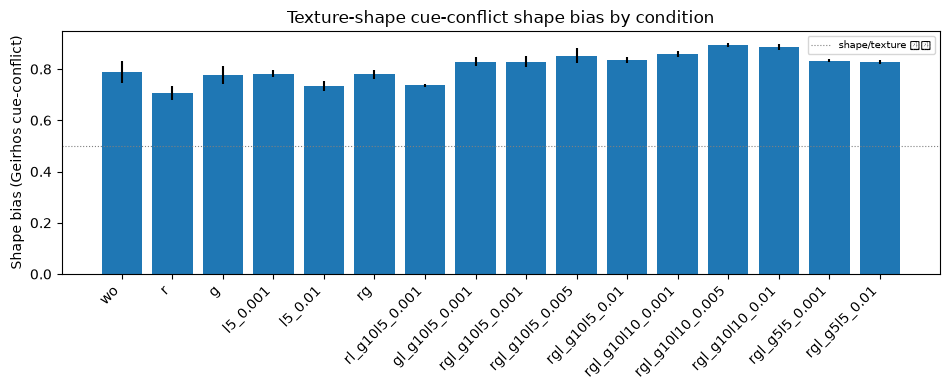

In [24]:
tags = list(geirhos_results.keys())
means = [np.nanmean(geirhos_results[t]) for t in tags]
stds = [np.nanstd(geirhos_results[t]) for t in tags]

plt.figure(figsize=(max(6, len(tags) * 0.6), 4))
plt.bar(range(len(tags)), means, yerr=stds)
plt.axhline(0.5, linestyle=':', color='gray', linewidth=0.8, label='shape/texture 반반')
plt.xticks(range(len(tags)), tags, rotation=45, ha='right')
plt.ylabel("Shape bias (Geirhos cue-conflict)")
plt.title("Texture-shape cue-conflict shape bias by condition")
plt.legend(fontsize=7)
plt.tight_layout()
if SAVE_FIGURES:
    plt.savefig(os.path.join(figure_dir, "05_geirhos_shape_bias.svg"))
plt.show()


C:\Users\vslab#1\AppData\Local\Temp\ipykernel_37304\4070652392.py:21: UserWarning: Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\vslab#1\Desktop\Chaewon\critical-period\gradual_cw\Gradual-sensory-maturation copy\gradual\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


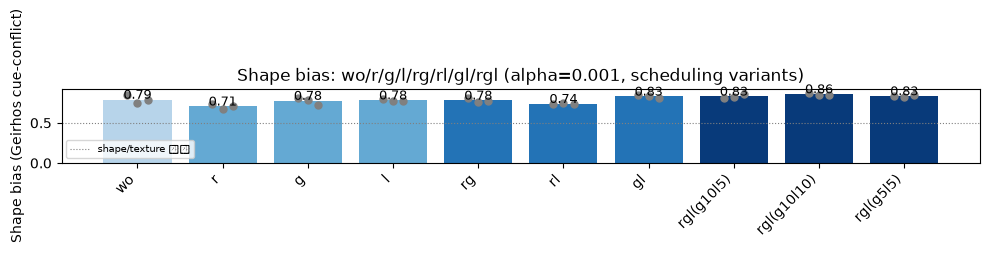

In [ ]:
# 5c. wo/r/g/l/rg/rl/gl/rgl 비교 (shape bias) -- 1c와 같은 조건 셋 / 막대 색(factor 진하기) 규칙 재사용
geirhos_schedule_tags = [t for t in schedule_tags_order if t in geirhos_results]

geirhos_means = [np.nanmean(geirhos_results[t]) for t in geirhos_schedule_tags]
geirhos_bar_colors = [cmap(0.3 + 0.22 * factor_count[t]) for t in geirhos_schedule_tags]

plt.figure(figsize=(10, 2))
plt.bar(range(len(geirhos_schedule_tags)), geirhos_means, color=geirhos_bar_colors, zorder=2)
for xi, tag in enumerate(geirhos_schedule_tags):
    accs = np.array(geirhos_results[tag])
    for off, acc in zip(dot_offsets, accs):
        plt.scatter(xi + off, acc, color="gray", s=25, zorder=3)
for xi, m in enumerate(geirhos_means):
    plt.text(xi, m + 0.01, f"{m:.2f}", ha="center", fontsize=9)

plt.axhline(0.5, linestyle=':', color='gray', linewidth=0.8, label='shape/te')
plt.xticks(range(len(geirhos_schedule_tags)), [schedule_labels[t] for t in geirhos_schedule_tags], fontsize=15)
plt.title("Shape bias", fontsize=20)
plt.legend(fontsize=15)
plt.tight_layout()
plt.show()

In [ ]:
# 5d. CIFAR-10-C 정확도 + shape bias (행동 수준 강건성 두 지표를 한 그래프에) -- 1c/5c와 같은 조건 셋/스타일 재사용
robustness_tags = [t for t in schedule_tags_order if t in corruption_results and t in geirhos_results]

def corruption_per_net_acc(tag):
    return [np.mean([acc for sevs in detail.values() for acc in sevs.values()]) for detail in corruption_detailed[tag]]

series_specs = [
    ("CIFAR-10-C acc", lambda t: np.array(corruption_per_net_acc(t)) * 100, "tab:blue"),
    ("shape bias", lambda t: np.array(geirhos_results[t]) * 100, "tab:orange"),
]
width = 0.35
x = np.arange(len(robustness_tags))

plt.figure(figsize=(max(8, len(robustness_tags) * 0.8), 4))
import matplotlib.colors as mcolors

for i, (name, getter, color) in enumerate(series_specs):
    xpos = x + (i - 0.5) * width
    means = [np.mean(getter(t)) for t in robustness_tags]
    alphas = [0.4 + 0.2 * factor_count[t] for t in robustness_tags]
    bar_colors = [mcolors.to_rgba(color, alpha=a) for a in alphas]  # matplotlib bar()는 alpha에 리스트를 못 받아서 색에 직접 섞음
    plt.bar(xpos, means, width, color=bar_colors, label=name, zorder=2)
    for xi, t in enumerate(robustness_tags):
        vals = getter(t)
        for off, v in zip(dot_offsets, vals):
            plt.scatter(xpos[xi] + off, v, color="black", s=10, zorder=3)
    for xi, m in enumerate(means):
        plt.text(xpos[xi], m + 1, f"{m:.1f}", ha="center", fontsize=6)

plt.xticks(x, [schedule_labels[t] for t in robustness_tags], rotation=45, ha="right")
plt.ylabel("%")
plt.title("Representation robustness (behavioral): CIFAR-10-C accuracy vs shape bias")
plt.legend()
plt.tight_layout()
plt.show()

### 5b. 실제로 texture을 따라간 이미지

`show_geirhos_texture_wins(tag, net_idx)` -- 모양 대신 texture 클래스로 예측한 cue-conflict
이미지들만 골라서 보여줌.

wo net0: 15/150 predicted texture instead of shape


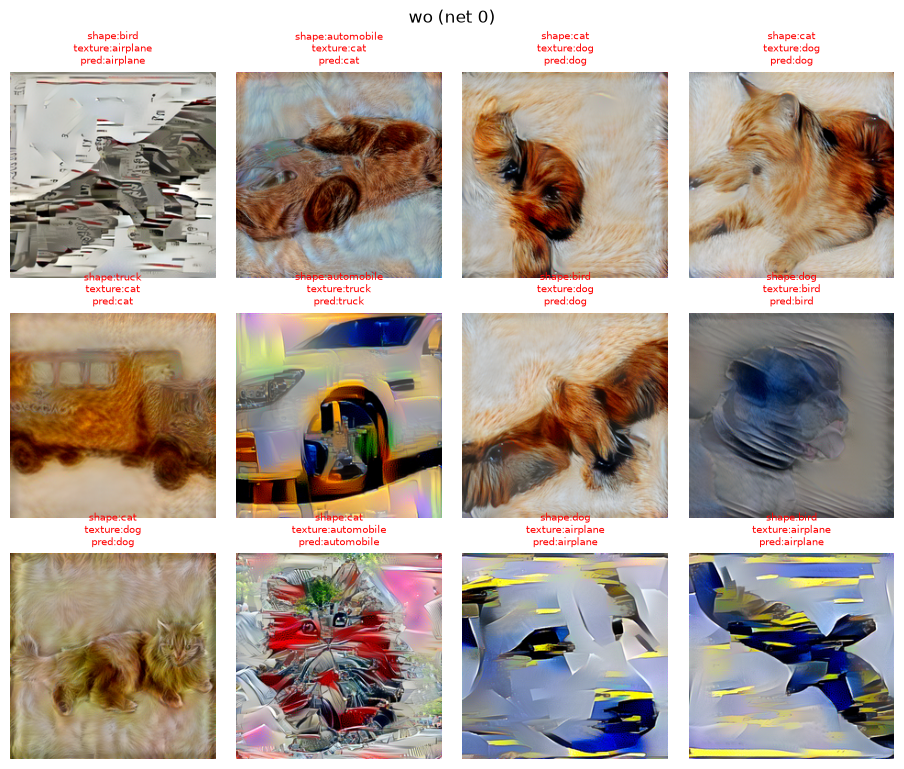

In [58]:
def show_geirhos_texture_wins(tag, net_idx=0, num_examples=12, seed=0, batch_size=64):
    """Geirhos cue-conflict에서 모양 대신 texture로 예측한 이미지들을 보여줌."""
    model = load_model(tag, net_idx)
    model.eval()
    texture_win_items = []
    with torch.no_grad():
        for i in range(0, len(geirhos_pairs), batch_size):
            batch = geirhos_pairs[i:i + batch_size]
            images = torch.stack([geirhos_transform(Image.open(p).convert("RGB")) for p, _, _ in batch]).to(device)
            logits = model(images)
            restricted = logits[:, OVERLAP_CIFAR_IDX]
            pred_idx = torch.tensor(OVERLAP_CIFAR_IDX, device=device)[restricted.argmax(1)]
            preds = pred_idx.cpu().tolist()
            for (path, shape_idx, texture_idx), pred in zip(batch, preds):
                if pred == texture_idx:
                    texture_win_items.append((path, shape_idx, texture_idx, pred))

    print(f"{tag} net{net_idx}: {len(texture_win_items)}/{len(geirhos_pairs)} predicted texture instead of shape")
    chosen_idx = np.random.RandomState(seed).choice(
        len(texture_win_items), min(num_examples, len(texture_win_items)), replace=False)

    def render(ax, ci):
        path, shape_idx, texture_idx, pred = texture_win_items[ci]
        ax.imshow(Image.open(path).convert("RGB"))
        ax.set_title(f"shape:{CIFAR10_CLASSES[shape_idx]}\ntexture:{CIFAR10_CLASSES[texture_idx]}\npred:{CIFAR10_CLASSES[pred]}",
                     fontsize=7, color="red")

    _grid_show(chosen_idx, render, f"{tag} (net {net_idx})")

show_geirhos_texture_wins("wo", 0)

#### 6. SVRT same-different relational reasoning (신규, linear probe)

- **Same**: 무작위 불규칙 폴리곤(blob) 한 개를 회전/반사/크기만 각각 독립적으로 바꿔서 두 위치에 배치
- **Different**: 서로 다른 무작위 폴리곤 두 개를 배치
- chance level = 50% 
원본이 C++이라 약간 다름. 

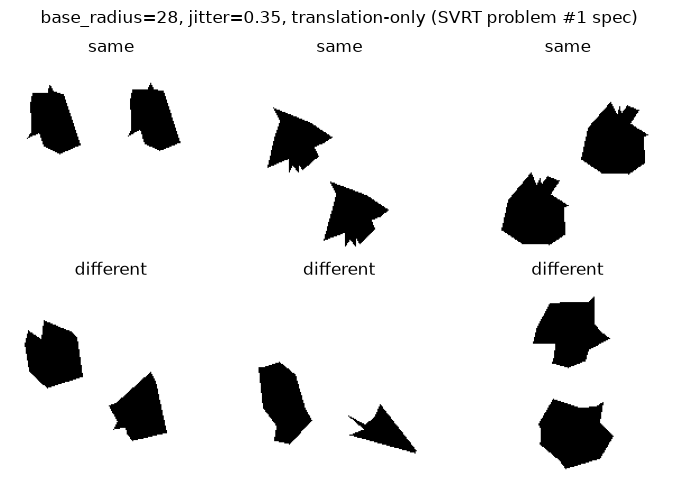

In [ ]:
from PIL import ImageDraw

# SVRT problem #1 원래 스펙: "same"은 회전/반사/크기 없이 위치(translation)만 다름.
# base_radius=28, jitter=0.35로 도형을 크고 뚜렷하게 그림 -- 32x32로 줄여도 디테일이 덜 뭉개짐.


def random_blob_polygon(rng, num_vertices=None, base_radius=28, jitter=0.5):
    """중심이 원점인 불규칙 폐곡선(blob) 폴리곤 -- SVRT의 'island' 도형과 같은 발상."""
    num_vertices = num_vertices or rng.randint(8, 16)
    angles = np.sort(rng.uniform(0, 2 * np.pi, num_vertices))
    radii = base_radius * (1 + rng.uniform(-jitter, jitter, num_vertices))
    return np.stack([radii * np.cos(angles), radii * np.sin(angles)], axis=1)


def sample_two_centers(rng, image_size, safe_radius, min_gap):
    """중심1은 캔버스 안 아무데나, 중심2는 중심1로부터 min_gap 이상 떨어진 방향/거리로 직접 배치.
    (예전 버전은 두 점을 각각 독립적으로 뽑고 거리 조건을 만족할 때까지 재시도했는데,
    필요한 최소 거리가 캔버스 대각선에 너무 가까워서 200번 안에 못 찾고 겹치는 상태로
    fallback되는 경우가 실제로 있었음 -- 그래서 방식 자체를 바꿈.)"""
    lo, hi = safe_radius, image_size - safe_radius
    for _ in range(500):
        c1 = rng.uniform(lo, hi, size=2)
        angle = rng.uniform(0, 2 * np.pi)
        dist = rng.uniform(min_gap, min_gap * 1.6)
        c2 = c1 + dist * np.array([np.cos(angle), np.sin(angle)])
        if lo <= c2[0] <= hi and lo <= c2[1] <= hi:
            return c1, c2
    return c1, c2  # 극히 드문 경우에만 fallback -- 그래도 min_gap 자체는 만족 못 할 수 있음


def generate_svrt_example(same, rng, image_size=180, base_radius=28, jitter=0.35):
    safe_radius = base_radius * 1.4   # jitter 최대치(1+jitter)를 감안해도 캔버스 밖으로 안 나가게
    min_gap = base_radius * 2.8       # 두 도형의 jitter 최대 반지름 합(2*(1+jitter)*base_radius)보다 넉넉하게
    base_pts = random_blob_polygon(rng, base_radius=base_radius, jitter=jitter)
    center_a, center_b = sample_two_centers(rng, image_size, safe_radius, min_gap)

    pts_a = base_pts + np.array(center_a)
    other_pts = base_pts if same else random_blob_polygon(rng, base_radius=base_radius, jitter=jitter)
    pts_b = other_pts + np.array(center_b)

    img = Image.new("L", (image_size, image_size), color=255)
    draw = ImageDraw.Draw(img)
    draw.polygon([tuple(pt) for pt in pts_a], fill=0)
    draw.polygon([tuple(pt) for pt in pts_b], fill=0)
    return img


# 육안 확인: same 3장 + different 3장
fig, axes = plt.subplots(2, 3, figsize=(7, 5))
rng_preview = np.random.RandomState(123)
for col in range(3):
    axes[0, col].imshow(generate_svrt_example(True, rng_preview), cmap="gray")
    axes[0, col].set_title("same"); axes[0, col].axis("off")
    axes[1, col].imshow(generate_svrt_example(False, rng_preview), cmap="gray")
    axes[1, col].set_title("different"); axes[1, col].axis("off")
plt.tight_layout()
plt.show()

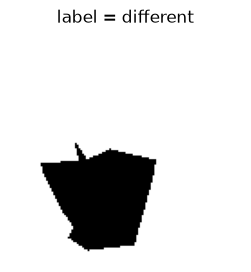

C:\Users\vslab#1\AppData\Local\Temp\ipykernel_37304\2116128756.py:43: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\vslab#1\AppData\Local\Temp\ipykernel_37304\2116128756.py:43: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\vslab#1\AppData\Local\Temp\ipykernel_37304\2116128756.py:43: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\vslab#1\AppData\Local\Temp\ipykernel_37304\2116128756.py:43: UserWarning: Glyph 45944 (\N{HANGUL SYLLABLE DEL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\vslab#1\AppData\Local\Temp\ipykernel_37304\2116128756.py:43: UserWarning: Glyph 51077 (\N{HANGUL SYLLABLE IB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\vslab#1\AppData\Local\Temp\ipykernel_37304\2116128756.py:43: UserWarning: Glyph 47141 (\N{HANGUL SYLLABLE RYEOG}

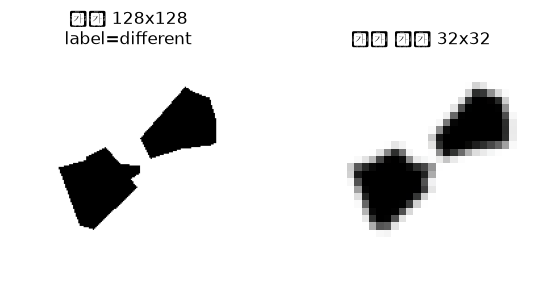

In [61]:
svrt_transform = T.Compose([
    T.Resize((32, 32)),
    T.Grayscale(num_output_channels=3),  # 학습된 모델이 3채널 입력을 기대함
    T.ToTensor(),
    T.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])


def show_svrt_example(same=None, seed=None, image_size=128):
    """직접 호출해서 이미지 하나씩 확인용. same=None이면 무작위로 same/different 결정.
    예: show_svrt_example()  /  show_svrt_example(same=True, seed=7)"""
    rng = np.random.RandomState(seed) if seed is not None else np.random.RandomState()
    if same is None:
        same = bool(rng.random() < 0.5)
    img = generate_svrt_example(same, rng, image_size=image_size)
    plt.figure(figsize=(3, 3))
    plt.imshow(img, cmap="gray", vmin=0, vmax=255)
    plt.title(f"label = {'same' if same else 'different'}")
    plt.axis("off")
    plt.show()
    return img


def show_svrt_as_model_input(same=None, seed=None):
    """모델이 실제로 보는 형태(32x32 리사이즈 + 정규화)까지 원본이랑 나란히 비교.
    다운샘플로 도형 디테일이 뭉개지는지 눈으로 확인하는 용도."""
    rng = np.random.RandomState(seed) if seed is not None else np.random.RandomState()
    if same is None:
        same = bool(rng.random() < 0.5)
    img_raw = generate_svrt_example(same, rng)
    x = svrt_transform(img_raw)  # (3, 32, 32), 정규화됨
    mean = torch.tensor(CIFAR10_MEAN).view(3, 1, 1)
    std = torch.tensor(CIFAR10_STD).view(3, 1, 1)
    img_model = (x * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

    fig, axes = plt.subplots(1, 2, figsize=(6, 3))
    axes[0].imshow(img_raw, cmap="gray", vmin=0, vmax=255)
    axes[0].set_title(f"원본 128x128\nlabel={'same' if same else 'different'}")
    axes[0].axis("off")
    axes[1].imshow(img_model)
    axes[1].set_title("모델 입력 32x32")
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()


show_svrt_example()
show_svrt_as_model_input()

In [62]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# svrt_transform은 위 미리보기 셀에서 이미 정의됨

N_SVRT_TRAIN, N_SVRT_TEST = 2000, 500


def build_svrt_split(n, rng):
    images, labels = [], []
    for _ in range(n):
        same = rng.random() < 0.5
        images.append(svrt_transform(generate_svrt_example(same, rng)))
        labels.append(int(same))
    return torch.stack(images), np.array(labels)


svrt_rng = np.random.RandomState(42)
svrt_train_x, svrt_train_y = build_svrt_split(N_SVRT_TRAIN, svrt_rng)
svrt_test_x, svrt_test_y = build_svrt_split(N_SVRT_TEST, svrt_rng)
print(f"SVRT train={len(svrt_train_x)} (same={svrt_train_y.sum()}), test={len(svrt_test_x)} (same={svrt_test_y.sum()})")


@torch.no_grad()
def extract_features_tensor(model, images, batch_size=256):
    """resnet18의 avg_pool 출력(512차원)을 penultimate feature로 사용 -- representation.ipynb와 동일 컨벤션."""
    feats_out = []

    def hook_fn(module, inp, out):
        feats_out.append(torch.flatten(out, 1).cpu().numpy())

    handle = model.avg_pool.register_forward_hook(hook_fn)
    for i in range(0, len(images), batch_size):
        model(images[i:i + batch_size].to(device))
    handle.remove()
    return np.concatenate(feats_out)


SVRT train=2000 (same=1009), test=500 (same=255)


In [63]:
svrt_results = {}
for tag in available_tags:
    accs = []
    for net_idx in range(num_net):
        model = load_model(tag, net_idx)
        train_feats = extract_features_tensor(model, svrt_train_x)
        test_feats = extract_features_tensor(model, svrt_test_x)

        scaler = StandardScaler().fit(train_feats)
        clf = LogisticRegression(max_iter=2000, C=1.0)
        clf.fit(scaler.transform(train_feats), svrt_train_y)
        acc = clf.score(scaler.transform(test_feats), svrt_test_y)
        accs.append(acc)
    svrt_results[tag] = accs
    print(f"{tag:16s}: SVRT same-different probe acc {np.mean(accs)*100:.2f} (+/- {np.std(accs)*100:.2f})")


wo              : SVRT same-different probe acc 59.33 (+/- 1.23)
r               : SVRT same-different probe acc 62.33 (+/- 1.47)
g               : SVRT same-different probe acc 58.00 (+/- 1.07)
l5_0.001        : SVRT same-different probe acc 59.80 (+/- 0.91)
l5_0.01         : SVRT same-different probe acc 59.67 (+/- 0.96)
rg              : SVRT same-different probe acc 61.33 (+/- 1.36)
rl_g10l5_0.001  : SVRT same-different probe acc 64.67 (+/- 1.32)
gl_g10l5_0.001  : SVRT same-different probe acc 60.60 (+/- 2.01)
rgl_g10l5_0.001 : SVRT same-different probe acc 61.40 (+/- 1.31)
rgl_g10l5_0.005 : SVRT same-different probe acc 61.93 (+/- 0.90)
rgl_g10l5_0.01  : SVRT same-different probe acc 58.87 (+/- 0.62)
rgl_g10l10_0.001: SVRT same-different probe acc 63.07 (+/- 0.77)
rgl_g10l10_0.005: SVRT same-different probe acc 60.40 (+/- 1.14)
rgl_g10l10_0.01 : SVRT same-different probe acc 58.40 (+/- 0.49)
rgl_g5l5_0.001  : SVRT same-different probe acc 63.93 (+/- 2.78)
rgl_g5l5_0.01   : SVRT sa

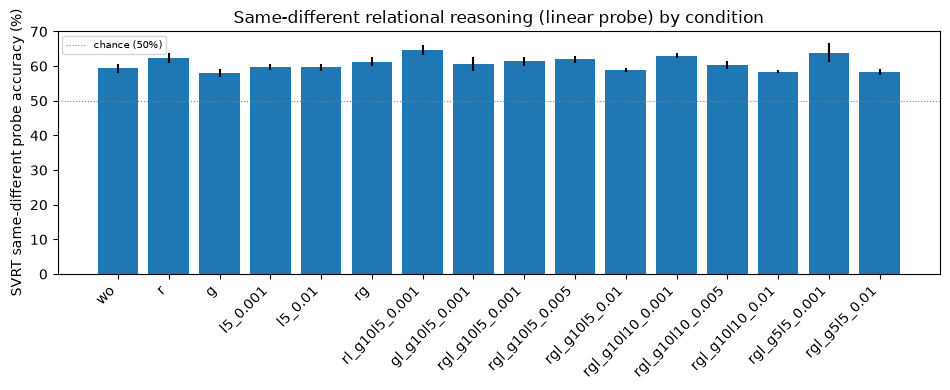

In [64]:
tags = list(svrt_results.keys())
means = [np.mean(svrt_results[t]) * 100 for t in tags]
stds = [np.std(svrt_results[t]) * 100 for t in tags]

plt.figure(figsize=(max(6, len(tags) * 0.6), 4))
plt.bar(range(len(tags)), means, yerr=stds)
plt.axhline(50, linestyle=':', color='gray', linewidth=0.8, label='chance (50%)')
plt.xticks(range(len(tags)), tags, rotation=45, ha='right')
plt.ylabel("SVRT same-different probe accuracy (%)")
plt.title("Same-different relational reasoning (linear probe) by condition")
plt.legend(fontsize=7)
plt.tight_layout()
if SAVE_FIGURES:
    plt.savefig(os.path.join(figure_dir, "06_svrt_same_different.svg"))
plt.show()
